# Water Segmentation — Transfer Learning (EfficientNet-B4 + U-Net)

In [1]:
# install what we need on top of the usual
!pip install -q rasterio segmentation-models-pytorch scikit-learn

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms.functional as TF
import segmentation_models_pytorch as smp
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from sklearn.metrics import jaccard_score, f1_score, precision_score, recall_score

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {DEVICE}')
if DEVICE == 'cpu':
    print('no GPU — go to Runtime > Change runtime type > GPU')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.9 MB/s eta 0:00:00
device: cuda


In [2]:
# mount drive and point to your data
from google.colab import drive
drive.mount('/content/drive')

IMAGES_DIR = '/content/drive/MyDrive/Satellite Image/data/images'
LABELS_DIR = '/content/drive/MyDrive/Satellite Image/data/labels'

# if path is wrong uncomment this to find your folder
# print(os.listdir('/content/drive/MyDrive/'))

img_files = [f for f in os.listdir(IMAGES_DIR) if f.endswith(('.tif', '.tiff'))]
lbl_files = [f for f in os.listdir(LABELS_DIR) if f.endswith('.png')]
print(f'images: {len(img_files)}  labels: {len(lbl_files)}')

Mounted at /content/drive


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Satellite Image/data/images'

In [ ]:
# check label values so we know if they are [0,1] or [0,255]
sample_lbl  = np.array(Image.open(os.path.join(LABELS_DIR, lbl_files[0])))
unique_vals = np.unique(sample_lbl)
print(f'label unique values: {unique_vals}')

# if labels are already [0,1] we do not divide — just threshold
# if labels are [0,255] we divide by 255
LABEL_SCALE = 255 if 255 in unique_vals else 1
print(f'label scale: {LABEL_SCALE}')

label unique values: [0 1]
label scale: 1


In [ ]:
# check QA band actual values in our dataset before deciding normalization
# the mentor flagged that we should verify this against our data, not just assume
qa_vals = []
for f in img_files[:30]:  # sample 30 files, enough to see the distribution
    with rasterio.open(os.path.join(IMAGES_DIR, f)) as src:
        qa = src.read(8).flatten()  # band 8 = index 7, but rasterio uses 1-based
        qa_vals.extend(qa.tolist())

qa_vals = np.array(qa_vals)
print(f'QA band unique values (sample of 30 files): {np.unique(qa_vals)}')
print(f'QA band min: {qa_vals.min()}  max: {qa_vals.max()}')

# if you see 64, 128, 160 → Landsat QA flags, use fixed range [64, 160]
# if you see other values  → use min-max like every other band

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


QA band unique values (sample of 30 files): [ 64  66  68  70  72  76  80  84  96 100 112 116 128 130 132 134 144 148
 160 164 176 192 194 196 198 208 224 228 240 244 255]
QA band min: 64  max: 255


In [ ]:
# load everything raw first — normalization comes after on the full dataset
def load_raw(images_dir, labels_dir, label_scale):
    img_dict = {os.path.splitext(f)[0]: f for f in os.listdir(images_dir) if f.endswith(('.tif','.tiff'))}
    lbl_dict = {os.path.splitext(f)[0]: f for f in os.listdir(labels_dir) if f.endswith('.png')}

    common = sorted(
        img_dict.keys() & lbl_dict.keys(),
        key=lambda x: int(x.split('_')[0])
    )

    print(f'images: {len(img_dict)}  labels: {len(lbl_dict)}  matched: {len(common)}')

    X_list, Y_list = [], []
    for stem in tqdm(common, desc='loading'):
        with rasterio.open(os.path.join(images_dir, img_dict[stem])) as src:
            img = src.read().astype(np.float32)

        lbl = np.array(Image.open(os.path.join(labels_dir, lbl_dict[stem])), dtype=np.float32)
        if lbl.ndim == 3:
            lbl = lbl[:, :, 0]
        # labels verified as [0,1] — just threshold, no divide needed if scale=1
        lbl = (lbl / label_scale > 0.5).astype(np.float32)

        X_list.append(img)
        Y_list.append(lbl)

    return np.stack(X_list), np.stack(Y_list)

X_raw, Y = load_raw(IMAGES_DIR, LABELS_DIR, LABEL_SCALE)
print(f'X: {X_raw.shape}  Y: {Y.shape}')
print(f'water ratio: {100*Y.mean():.1f}%')

images: 306  labels: 456  matched: 306


loading: 100%|██████████| 306/306 [01:14<00:00,  4.11it/s]

X: (306, 12, 128, 128)  Y: (306, 128, 128)
water ratio: 26.0%


In [ ]:
# check the actual distribution of each band across the full dataset
# this is what the mentor asked for — see where the values actually sit
BAND_NAMES = [
    'Coastal Aerosol', 'Blue', 'Green', 'Red',
    'NIR', 'SWIR1', 'SWIR2', 'QA Band',
    'Merit DEM', 'Copernicus DEM', 'ESA Land Cover', 'Water Occurrence'
]

print(f'{"#":<4} {"Band":<22} {"Min":>8} {"P2":>8} {"P50":>8} {"P98":>8} {"Max":>8}')
print('-' * 65)
for b in range(X_raw.shape[1]):
    band = X_raw[:, b, :, :].flatten()
    print(f'{b+1:<4} {BAND_NAMES[b]:<22} '
          f'{band.min():>8.1f} '
          f'{np.percentile(band,2):>8.1f} '
          f'{np.percentile(band,50):>8.1f} '
          f'{np.percentile(band,98):>8.1f} '
          f'{band.max():>8.1f}')

#    Band                        Min       P2      P50      P98      Max
-----------------------------------------------------------------
1    Coastal Aerosol         -1393.0     69.0    363.0    941.0   6568.0
2    Blue                    -1169.0    100.0    458.0   1143.0   9659.0
3    Green                    -722.0    233.0    775.0   1733.0  11368.0
4    Red                      -684.0    104.0    904.0   2478.0  12041.0
5    NIR                      -412.0    127.0   2164.0   4046.0  15841.0
6    SWIR1                    -335.0     14.0   1987.0   4453.0  15252.0
7    SWIR2                    -258.0     11.0   1251.0   3761.0  14647.0
8    QA Band                    64.0     64.0     64.0    224.0    255.0
9    Merit DEM               -9999.0     14.0    119.0   1890.0   4245.0
10   Copernicus DEM              8.0     17.0    119.0   1907.0   4287.0
11   ESA Land Cover             10.0     10.0     40.0     80.0    100.0
12   Water Occurrence            0.0      0.0      0.0    

In [ ]:
# normalize — percentile clipping per band across the whole dataset
# using 2nd-98th percentile prevents outlier pixels from compressing everything else
# QA band: use fixed range if values are [64,160], otherwise falls back to percentile
def normalize(X, qa_fixed=True):
    X_norm = np.zeros_like(X, dtype=np.float32)
    for b in range(X.shape[1]):
        band = X[:, b, :, :].copy()
        band = np.clip(band, 0, None)  # clip negatives from atmospheric correction

        if b == 7 and qa_fixed:  # QA band
            lo, hi = 64.0, 160.0
        else:
            lo = np.percentile(band, 2)
            hi = np.percentile(band, 98)

        X_norm[:, b] = np.clip((band - lo) / (hi - lo + 1e-6), 0, 1)

    return X_norm

# set qa_fixed=False if your QA band check above showed different values than 64/160
X = normalize(X_raw, qa_fixed=True)
X = np.nan_to_num(X, nan=0.0, posinf=1.0, neginf=0.0)

print(f'after normalization — min:{X.min():.3f}  max:{X.max():.3f}  nan:{np.isnan(X).any()}')

after normalization — min:0.000  max:1.000  nan:False


In [ ]:
# compute pos_weight for the loss — penalizes missing water based on actual class ratio
avg_water        = Y.mean()
pos_weight_value = (1 - avg_water) / avg_water
print(f'water ratio: {100*avg_water:.1f}%  →  pos_weight: {pos_weight_value:.2f}')

water ratio: 26.0%  →  pos_weight: 2.85


In [ ]:
# dataset with augmentation on train, nothing on val
class WaterDataset(Dataset):
    def __init__(self, X, Y, augment=False):
        self.X       = torch.tensor(X, dtype=torch.float32)
        self.Y       = torch.tensor(Y, dtype=torch.float32).unsqueeze(1)
        self.augment = augment

    def __len__(self): return len(self.X)

    def __getitem__(self, idx):
        x, y = self.X[idx], self.Y[idx]
        if self.augment:
            if random.random() > 0.5:
                x = TF.hflip(x); y = TF.hflip(y)
            if random.random() > 0.5:
                x = TF.vflip(x); y = TF.vflip(y)
            k = random.randint(0, 3)
            if k > 0:
                x = torch.rot90(x, k, dims=[1,2])
                y = torch.rot90(y, k, dims=[1,2])
        return x, y


# split indices first, then build separate datasets with correct augment flag
n         = len(X)
indices   = np.random.RandomState(42).permutation(n)
split     = int(0.8 * n)
train_idx = indices[:split]
val_idx   = indices[split:]

train_ds = WaterDataset(X[train_idx], Y[train_idx], augment=True)
val_ds   = WaterDataset(X[val_idx],   Y[val_idx],   augment=False)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

print(f'train: {len(train_ds)}  val: {len(val_ds)}')

train: 244  val: 62


In [ ]:
# EfficientNet-B4 encoder with U-Net decoder from segmentation_models_pytorch
# in_channels=12 tells smp to replace the first conv layer to accept our 12 bands
# all weights stay trainable — no freezing, as the mentor specified
model = smp.Unet(
    encoder_name    = 'efficientnet-b4',
    encoder_weights = 'imagenet',
    in_channels     = 12,
    classes         = 1,
    activation      = None          # raw logits, sigmoid applied inside loss
).to(DEVICE)

# make sure everything is trainable
for param in model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'trainable params: {trainable:,}')

# quick shape check
with torch.no_grad():
    out = model(torch.randn(2, 12, 128, 128).to(DEVICE))
print(f'output shape: {out.shape}  ← should be (2, 1, 128, 128)')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

trainable params: 20,229,577
output shape: torch.Size([2, 1, 128, 128])  ← should be (2, 1, 128, 128)


In [ ]:
import torch.optim as optim
import torch.nn as nn

# BCE + Dice loss — same as before, weighted for class imbalance
class BCEDiceLoss(nn.Module):
    def __init__(self, pos_weight, smooth=1e-6):
        super().__init__()
        self.bce    = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(DEVICE))
        self.smooth = smooth

    def dice_loss(self, pred, target):
        pred   = torch.sigmoid(pred).view(-1)
        target = target.view(-1)
        inter  = (pred * target).sum()
        return 1 - (2. * inter + self.smooth) / (pred.sum() + target.sum() + self.smooth)

    def forward(self, pred, target):
        return self.bce(pred, target) + self.dice_loss(pred, target)


criterion = BCEDiceLoss(pos_weight=pos_weight_value)

# OneCycleLR works better than ReduceLROnPlateau for transfer learning
# it does a warmup then cosine decay, which is what you want when fine-tuning
EPOCHS    = 100
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr          = 1e-3,
    epochs          = EPOCHS,
    steps_per_epoch = len(train_loader)
)

print('loss      : BCE (weighted) + Dice')
print('optimizer : AdamW')
print('scheduler : OneCycleLR  max_lr=1e-3  warmup then cosine decay')

loss      : BCE (weighted) + Dice
optimizer : AdamW
scheduler : OneCycleLR  max_lr=1e-3  warmup then cosine decay


In [ ]:
def train_epoch(model, loader, optimizer, criterion, scheduler):
    model.train()
    total = 0
    for X_b, Y_b in tqdm(loader, desc='train', leave=False):
        X_b, Y_b = X_b.to(DEVICE), Y_b.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X_b), Y_b)
        loss.backward()
        optimizer.step()
        scheduler.step()   # OneCycleLR steps every batch, not every epoch
        total += loss.item()
    return total / len(loader)


@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    total, all_p, all_t = 0, [], []
    for X_b, Y_b in tqdm(loader, desc='val  ', leave=False):
        X_b, Y_b = X_b.to(DEVICE), Y_b.to(DEVICE)
        preds  = model(X_b)
        total += criterion(preds, Y_b).item()
        all_p.extend((torch.sigmoid(preds) > 0.5).cpu().numpy().flatten().astype(int))
        all_t.extend(Y_b.cpu().numpy().flatten().astype(int))
    iou  = jaccard_score(all_t, all_p, zero_division=0)
    f1   = f1_score(all_t, all_p, zero_division=0)
    prec = precision_score(all_t, all_p, zero_division=0)
    rec  = recall_score(all_t, all_p, zero_division=0)
    return total / len(loader), iou, f1, prec, rec


best_iou = 0.0
history  = {'train_loss': [], 'val_loss': [], 'iou': [], 'f1': []}

print(f'training for {EPOCHS} epochs on {DEVICE}\n')
print(f'{"Epoch":>6} | {"TrainLoss":>10} | {"ValLoss":>9} | {"IoU":>7} | {"F1":>7} | {"Prec":>7} | {"Rec":>7}')
print('-' * 72)

for epoch in range(1, EPOCHS + 1):
    tr = train_epoch(model, train_loader, optimizer, criterion, scheduler)
    vl, iou, f1, prec, rec = validate(model, val_loader, criterion)

    history['train_loss'].append(tr)
    history['val_loss'].append(vl)
    history['iou'].append(iou)
    history['f1'].append(f1)

    saved = ''
    if iou > best_iou:
        best_iou = iou
        torch.save(model.state_dict(), 'best_transfer.pth')
        saved = ' saved'

    print(f'{epoch:>6} | {tr:>10.4f} | {vl:>9.4f} | '
          f'{iou:>7.4f} | {f1:>7.4f} | {prec:>7.4f} | {rec:>7.4f}{saved}')

print(f'\nbest IoU: {best_iou:.4f}')

training for 100 epochs on cuda

 Epoch |  TrainLoss |   ValLoss |     IoU |      F1 |    Prec |     Rec
------------------------------------------------------------------------


     1 |     0.3619 |    0.4418 |  0.7392 |  0.8501 |  0.7800 |  0.9339 saved


     2 |     0.3476 |    0.4369 |  0.7512 |  0.8579 |  0.8013 |  0.9231 saved


     3 |     0.3476 |    0.4357 |  0.7454 |  0.8541 |  0.7894 |  0.9304


     4 |     0.3499 |    0.4341 |  0.7517 |  0.8583 |  0.8024 |  0.9224 saved


...

    96 |     0.2129 |    0.3562 |  0.8059 |  0.8925 |  0.8565 |  0.9317


    97 |     0.2135 |    0.3573 |  0.8079 |  0.8937 |  0.8621 |  0.9278


    98 |     0.2159 |    0.3557 |  0.8049 |  0.8919 |  0.8542 |  0.9331


    99 |     0.2133 |    0.3565 |  0.8043 |  0.8915 |  0.8526 |  0.9341


   100 |     0.2110 |    0.3560 |  0.7988 |  0.8881 |  0.8402 |  0.9419

best IoU: 0.8086


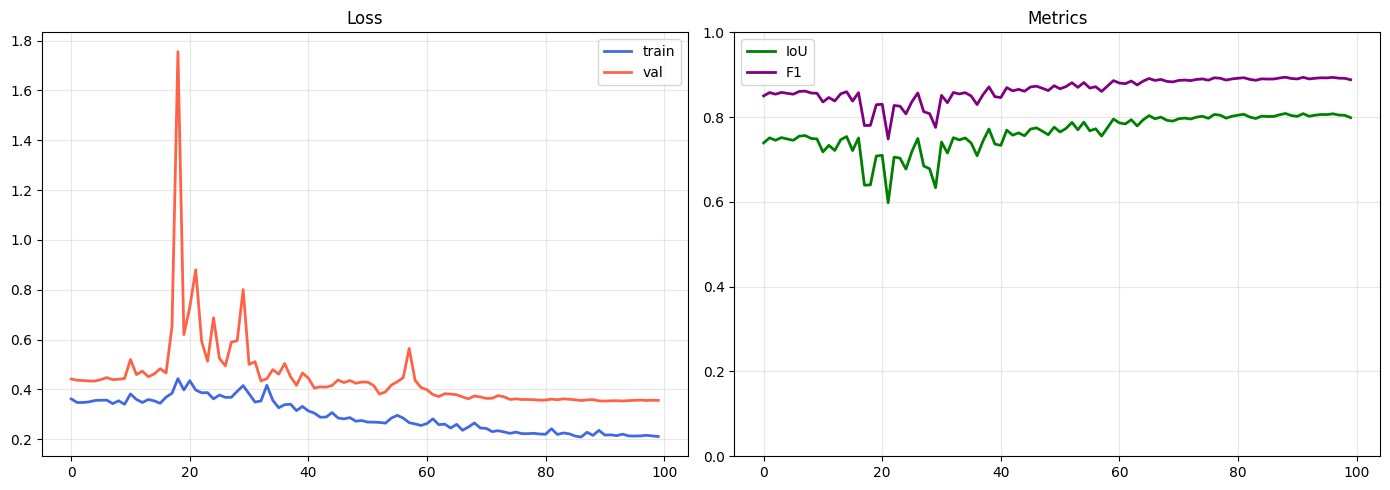

In [ ]:
# training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history['train_loss'], label='train', color='royalblue', lw=2)
axes[0].plot(history['val_loss'],   label='val',   color='tomato',    lw=2)
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history['iou'], label='IoU', color='green',  lw=2)
axes[1].plot(history['f1'],  label='F1',  color='purple', lw=2)
axes[1].set_title('Metrics'); axes[1].set_ylim(0, 1)
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('curves.png', dpi=120)
plt.show()

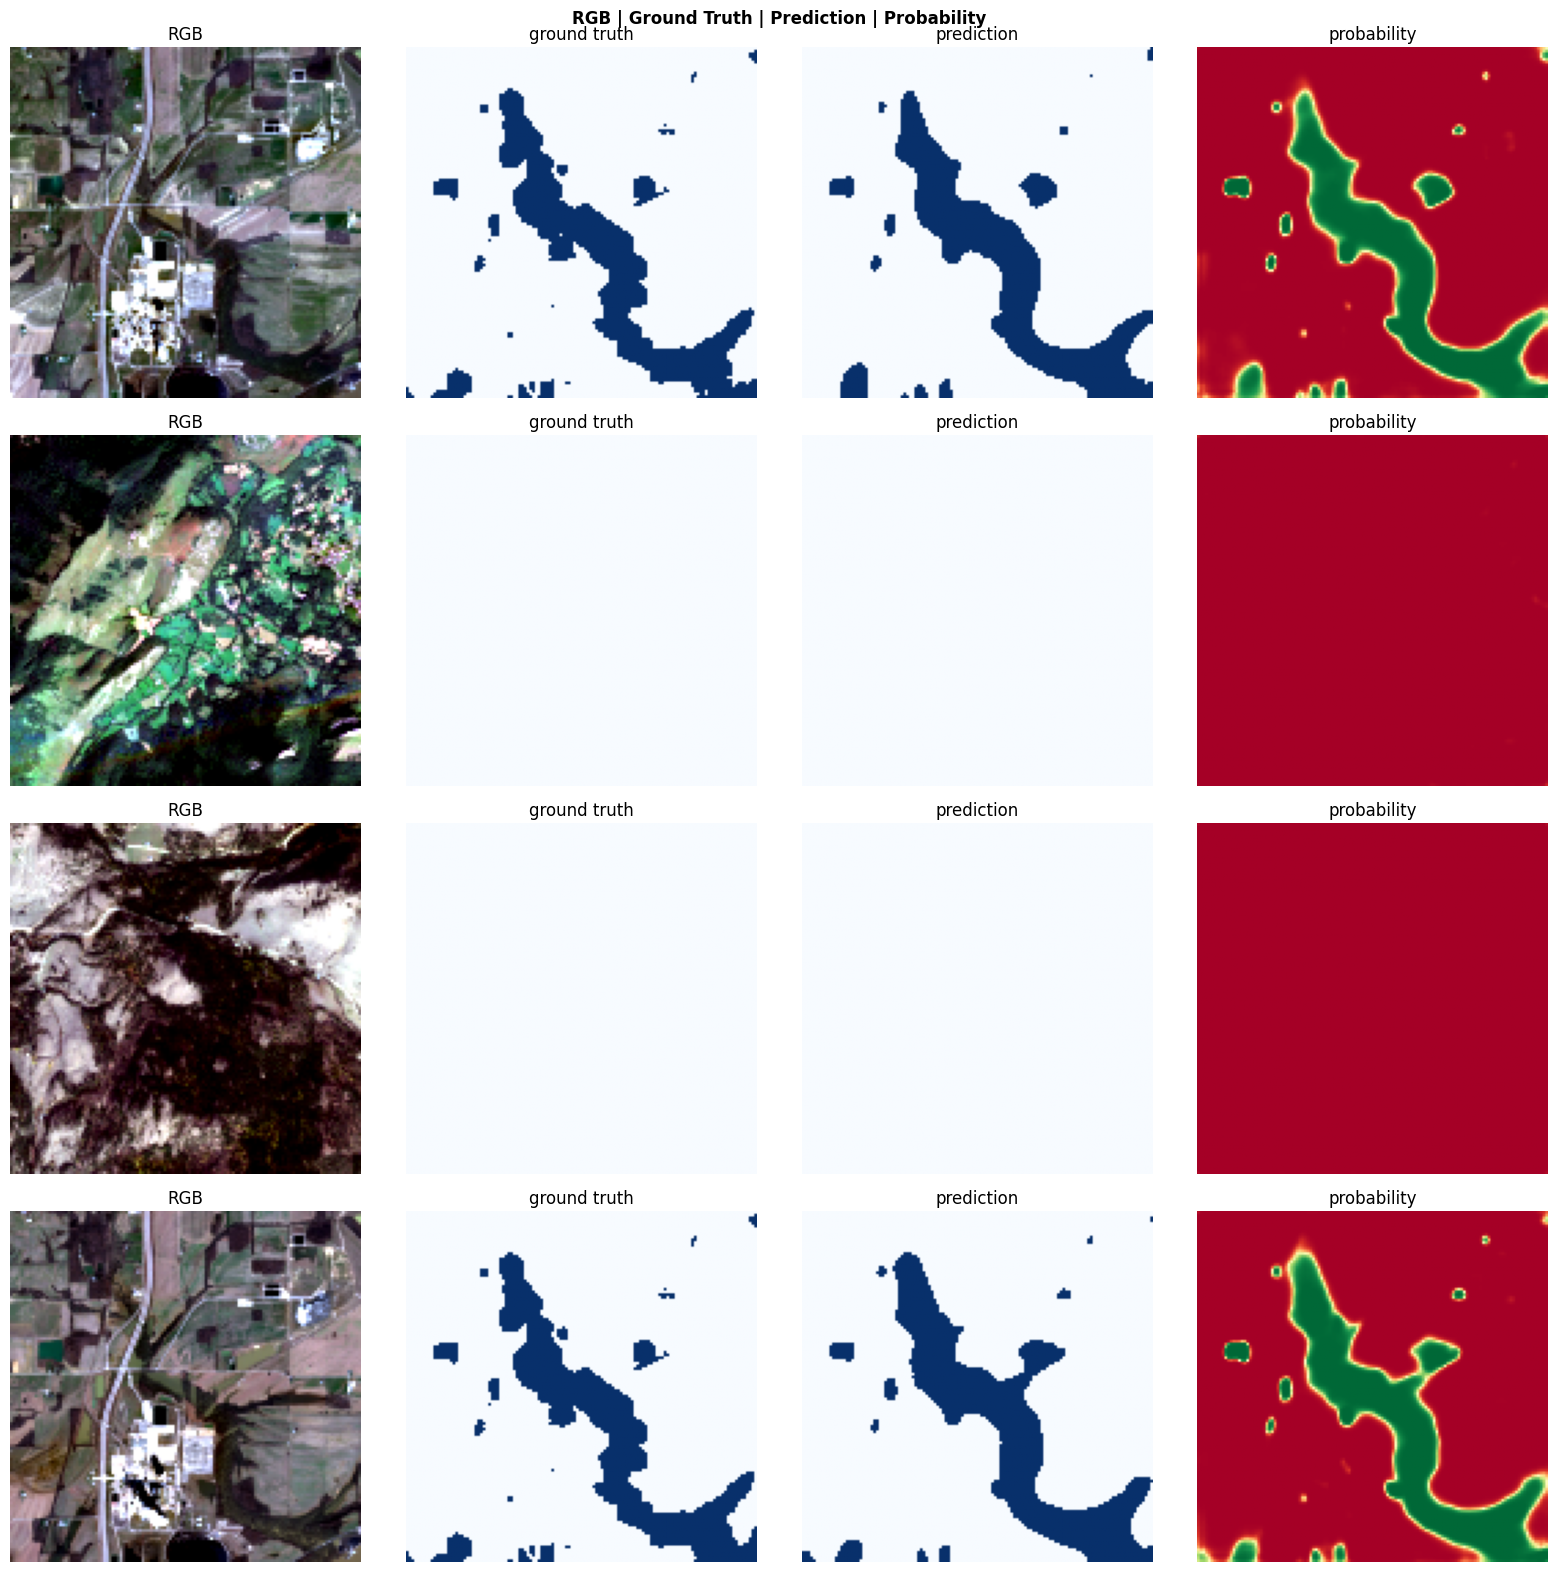

In [ ]:
# visualize predictions from best model
def make_rgb(img, r=3, g=2, b=1):
    rgb = np.stack([img[r], img[g], img[b]], axis=-1).astype(np.float32)
    for c in range(3):
        lo, hi = np.percentile(rgb[:,:,c], 2), np.percentile(rgb[:,:,c], 98)
        rgb[:,:,c] = np.clip((rgb[:,:,c] - lo) / (hi - lo + 1e-6), 0, 1)
    return rgb

model.load_state_dict(torch.load('best_transfer.pth', map_location=DEVICE))
model.eval()

X_vis, Y_vis = next(iter(val_loader))
with torch.no_grad():
    probs = torch.sigmoid(model(X_vis.to(DEVICE))).cpu().numpy()
preds = (probs > 0.5).astype(np.float32)

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for i in range(4):
    axes[i,0].imshow(make_rgb(X_vis[i].numpy()))
    axes[i,0].set_title('RGB');           axes[i,0].axis('off')
    axes[i,1].imshow(Y_vis[i,0], cmap='Blues', vmin=0, vmax=1)
    axes[i,1].set_title('ground truth');  axes[i,1].axis('off')
    axes[i,2].imshow(preds[i,0], cmap='Blues', vmin=0, vmax=1)
    axes[i,2].set_title('prediction');    axes[i,2].axis('off')
    axes[i,3].imshow(probs[i,0], cmap='RdYlGn', vmin=0, vmax=1)
    axes[i,3].set_title('probability');   axes[i,3].axis('off')
plt.suptitle('RGB | Ground Truth | Prediction | Probability', fontweight='bold')
plt.tight_layout()
plt.savefig('predictions.png', dpi=120)
plt.show()

In [ ]:
# final numbers
model.load_state_dict(torch.load('best_transfer.pth', map_location=DEVICE))
_, iou, f1, prec, rec = validate(model, val_loader, criterion)

print('final results')
print(f'  IoU       : {iou:.4f}')
print(f'  F1        : {f1:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')

final results
  IoU       : 0.8086
  F1        : 0.8942
  Precision : 0.8656
  Recall    : 0.9246
